# Marketing A/B Test: Does Showing an Ad Increase Conversion?

Analysis of a marketing experiment comparing conversion rates between users
exposed to an ad campaign versus a control group shown a Public Service
Announcement (PSA).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/marketing_AB.csv")
df.shape

(588101, 7)

In [10]:
df.head()
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
count,588101.000000,5.881010e+05,588101,588101,588101.000000,588101,588101.000000
unique,NaN,NaN,2,2,NaN,7,NaN
top,NaN,NaN,ad,False,NaN,Friday,NaN
freq,NaN,NaN,564577,573258,NaN,92608,NaN
mean,294050.000000,1.310692e+06,NaN,NaN,24.820876,NaN,14.469061
std,169770.279668,2.022260e+05,NaN,NaN,43.715181,NaN,4.834634
min,0.000000,9.000000e+05,NaN,NaN,1.000000,NaN,0.000000
25%,147025.000000,1.143190e+06,NaN,NaN,4.000000,NaN,11.000000
50%,294050.000000,1.313725e+06,NaN,NaN,13.000000,NaN,14.000000
75%,441075.000000,1.484088e+06,NaN,NaN,27.000000,NaN,18.000000


## 2. Treatment Group Distribution

Before analyzing results, we check the treatment/control split. This dataset
uses an intentionally imbalanced design (~96% ad / ~4% psa), which is common
in real ad campaigns — companies avoid allocating large traffic shares to a
control group once they already have enough statistical power with a smaller one.

In [15]:

df["test group"].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [18]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

## 3. Conversion Rate by Group

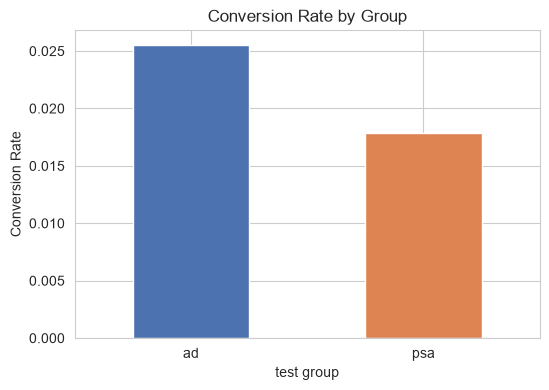

In [23]:
conversion_by_group = df.groupby("test group")["converted"].mean()

plt.figure(figsize=(6,4))
conversion_by_group.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

## 4. Experiment Design & Hypotheses

- **H0:** There is no difference in conversion rate between the "ad" and "psa" groups.
- **H1:** The "ad" group has a higher conversion rate than the "psa" group.
- **Test:** One-sided two-proportion z-test, since the business question is
  directional (does the ad increase conversion, not simply "is it different").
- **Significance level:** α = 0.05

In [ ]:
from statsmodels.stats.proportion import proportions_ztest


converted = df.groupby("test group")["converted"].sum()
n_obs = df.groupby("test group")["converted"].count()

count = [converted["ad"],converted["psa"]]
nobs = [n_obs["ad"],n_obs["psa"]]

## 5. Hypothesis Testing

z_stat, p_value = proportions_ztest(count,nobs,alternative="larger")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")



Z-statistic: 7.3701
P-value: 0.0000000000


## 6. Effect Size, Confidence Interval & Sample Size Check

A p-value alone doesn't convey magnitude, especially with a sample this large.
We estimate the confidence interval for the difference and check how much
sample size was actually required to detect this effect.

In [34]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_upp = confint_proportions_2indep(
    count1=converted["ad"], nobs1=n_obs["ad"],
    count2=converted["psa"], nobs2=n_obs["psa"],
    method="wald"
)
print(f"95% CI for the difference in conversion rate: ({ci_low:.4f}, {ci_upp:.4f})")

95% CI for the difference in conversion rate: (0.0060, 0.0094)


In [35]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(0.025547, 0.017854)
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative="larger")
print(f"Required sample size per group to detect this effect: {required_n:.0f}")

Required sample size per group to detect this effect: 4401


## 7. Validation with Chi-Square Test

In [36]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["test group"], df["converted"])
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.10f}")

Chi-square statistic: 54.0058
P-value: 0.0000000000


## 8. Business Interpretation

Users exposed to the ad converted at 2.55% vs. 1.79% for the control group —
an absolute lift of 0.60–0.94 percentage points (95% CI), and statistically
significant (p < 0.0001, confirmed by both z-test and chi-square).

The experiment used ~588,000 users, while only ~4,401 per group (~8,800 total)
were needed to detect this effect with 80% power — roughly 67x more sample
than required. This suggests the test could have concluded much faster or with
a smaller traffic allocation, freeing capacity for testing additional variants.

**Recommendation:** Roll out the ad campaign — the lift is both statistically
robust and practically meaningful.